In [2]:
from hmmlearn.hmm import GMMHMM
import datetime
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import cm
from matplotlib import pyplot as plt
import scipy.stats as scs 

### 时间轴也可直接做，比如现在的工作中不做我们前述所讲的处理，也可以做但效果不如自定义轴好，后续特征工程工作会比较复杂。

In [3]:
file ='RB99_1m_Momentum_Momentum_800_6031_930' #第3步中的轴文件
L=5#1阶与X阶，反映趋势的强弱程度
diff = 1     
mix = 3    ### GMM mix参数。
#在高斯混合隐马尔可夫模型中.n_mix 参数控制了模型对复杂数据分布的拟合能力。
# 较高的 mix 值可以捕获更复杂的数据模式，但也可能导致过拟合风险增加，计算资源需求增大。
file_name = file + '.csv'       
df = pd.read_csv(file_name)

# 从DataFrame中提取关键价格序列，并统一按滞后L期切片，保证后续特征对齐
close = df['close']                      # 完整收盘价序列，用于计算各类对数收益
high = df['high'][L:]                    # 去掉前L条最高价，与L阶特征对齐
low = df['low'][L:]                      # 去掉前L条最低价，与L阶特征对齐
eob = df['eob']                          # 原始时间戳列，先完整保留
datelist = pd.to_datetime(eob[L:])     # 同样去掉前L条时间戳，生成后续绘图/索引用的日期序列
# 计算1阶对数收益率：当前收盘价与前一期收盘价取对数后做差，并去掉前L-1条空值
# close[:-1] 表示“去掉最后一条记录后的收盘价序列”，
# 即与 close[1:]（去掉第一条记录后的序列）保持长度一致，
# 二者逐元素配对后可计算相邻两期的对数收益。
logreturn = (np.log(np.array(close[1:])) - np.log(np.array(close[:-1])))[(L-1):]

# 计算L阶对数收益率：当前收盘价与L期前收盘价取对数后做差
logreturnX = np.log(np.array(close[L:])) - np.log(np.array(close[:-L]))

# 计算高低价差的对数差分：对每日最高价与最低价取对数后做差
HLdiff = np.log(np.array(high)) - np.log(np.array(low))

# 截取与特征对齐后的收盘价序列，作为后续标签或索引使用
closeidx = close[L:]
# 类似与裸K的简单差分处理，HLdiff 是高低价格差的对数差分，
# logreturnX 是当前价格与前L个价格的对数差分，logreturn 是当前价格与前一个价格的对数差分。
# 生成X矩阵，用于GMM模型的输入。特征比较简单，只有3个特征。
# 根据 diff 标志决定特征矩阵 X 的列组合：
# diff == 1 时，把“高低价差对数差分 HLdiff”也作为特征，与 logreturnX、logreturn 一起拼成 3 列；
# diff != 1 时，仅保留 logreturnX 与 logreturn 两列。
if diff == 1:
    X = np.column_stack([HLdiff, logreturnX, logreturn])
else:
    X = np.column_stack([logreturnX, logreturn])

# 记录最终特征矩阵的样本量，方便后续调试或建模

print(X,len(X))


[[ 0.01172931 -0.02988786 -0.00674733]
 [ 0.01797816 -0.02671179  0.01046864]
 [ 0.00782104  0.00432532  0.0058444 ]
 ...
 [ 0.00745857 -0.01886661 -0.00034104]
 [ 0.00829069 -0.02102265 -0.00452094]
 [ 0.00909469 -0.00865517  0.00539745]] 6026


### 下面为数据通过GMM-HMM模型做标签，两种颜色代表“涨”、“跌”

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
6026


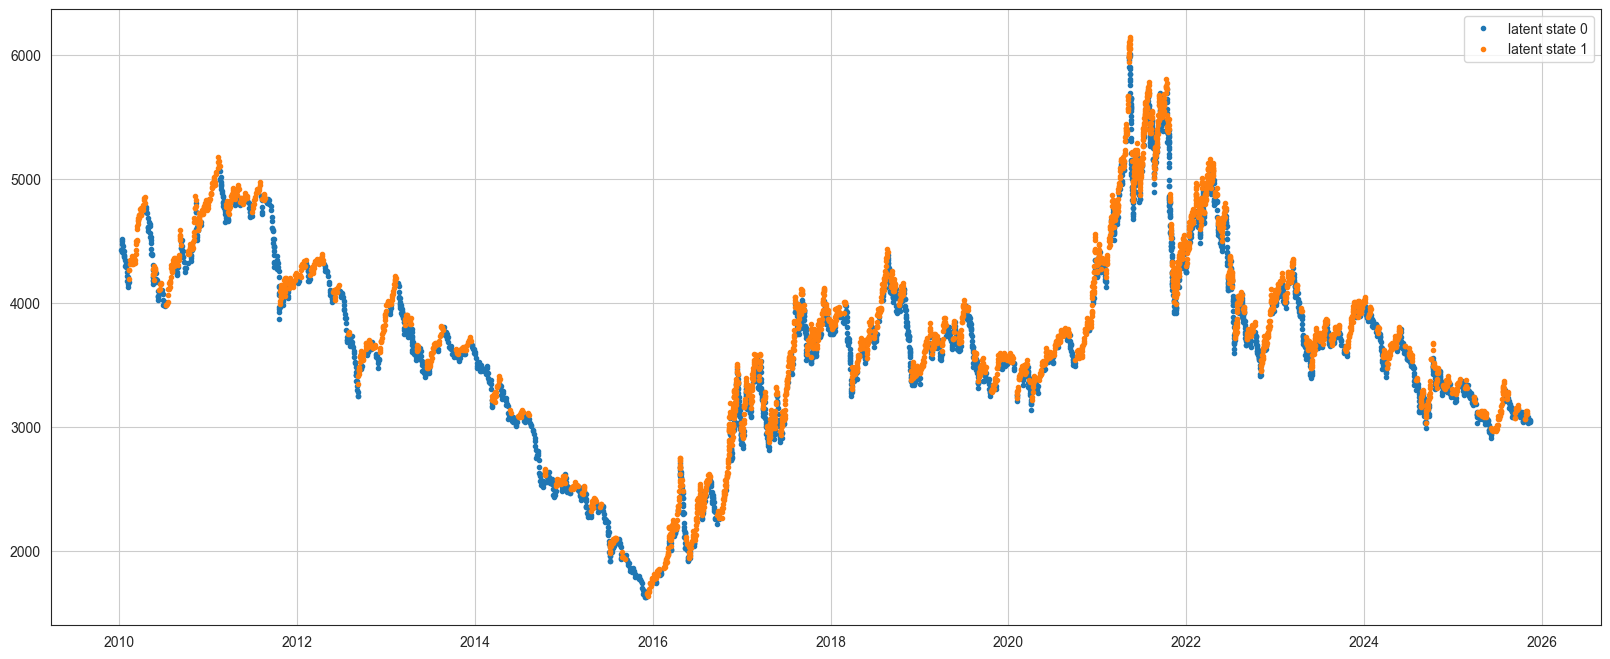

In [4]:
gmm = GMMHMM(n_components =2, n_mix=mix, covariance_type='diag', n_iter = 369, random_state = 369).fit(X)

latent_states_sequence = gmm.predict(X)
# [:25] 表示只打印 latent_states_sequence 的前 25 个元素
print(latent_states_sequence[:25])
# 计算 latent_states_sequence 的长度（即序列中隐藏状态的总数）
print(len(latent_states_sequence))
# 设置绘图风格为白色背景
sns.set_style('white')

# 创建画布，尺寸 20×8 英寸
plt.figure(figsize=(20, 8))

# 遍历 GMM-HMM 的每个隐藏状态
for i in range(gmm.n_components):
    # 取出当前状态对应的样本索引
    state = (latent_states_sequence == i)
    # 绘制该状态下的收盘价散点图
    plt.plot(datelist[state], closeidx[state], '.', label='latent state %d' % i, lw=1)

# 显示图例
plt.legend()
# 显示网格
plt.grid(1)


                     logreturn  state  state0_return  state1_return
datelist                                                           
2010-01-08 10:44:00  -0.006747      0      -0.000000           -0.0
2010-01-11 09:03:00   0.010469      0       0.010469            0.0
2010-01-11 13:41:00   0.005844      0       0.005844            0.0
2010-01-12 13:59:00   0.003062      0       0.003062            0.0
2010-01-13 09:06:00  -0.023470      0      -0.023470           -0.0
2010-01-13 10:45:00   0.007071      0       0.007071            0.0
2010-01-14 13:31:00   0.003911      0       0.003911            0.0
2010-01-15 11:28:00  -0.010867      0      -0.010867           -0.0
2010-01-18 09:34:00  -0.007067      0      -0.007067           -0.0
2010-01-19 09:06:00   0.010283      0       0.010283            0.0
2010-01-20 09:18:00  -0.007572      0      -0.007572           -0.0
2010-01-21 09:09:00  -0.004413      0      -0.004413           -0.0
2010-01-22 09:20:00  -0.006077      0      -0.00

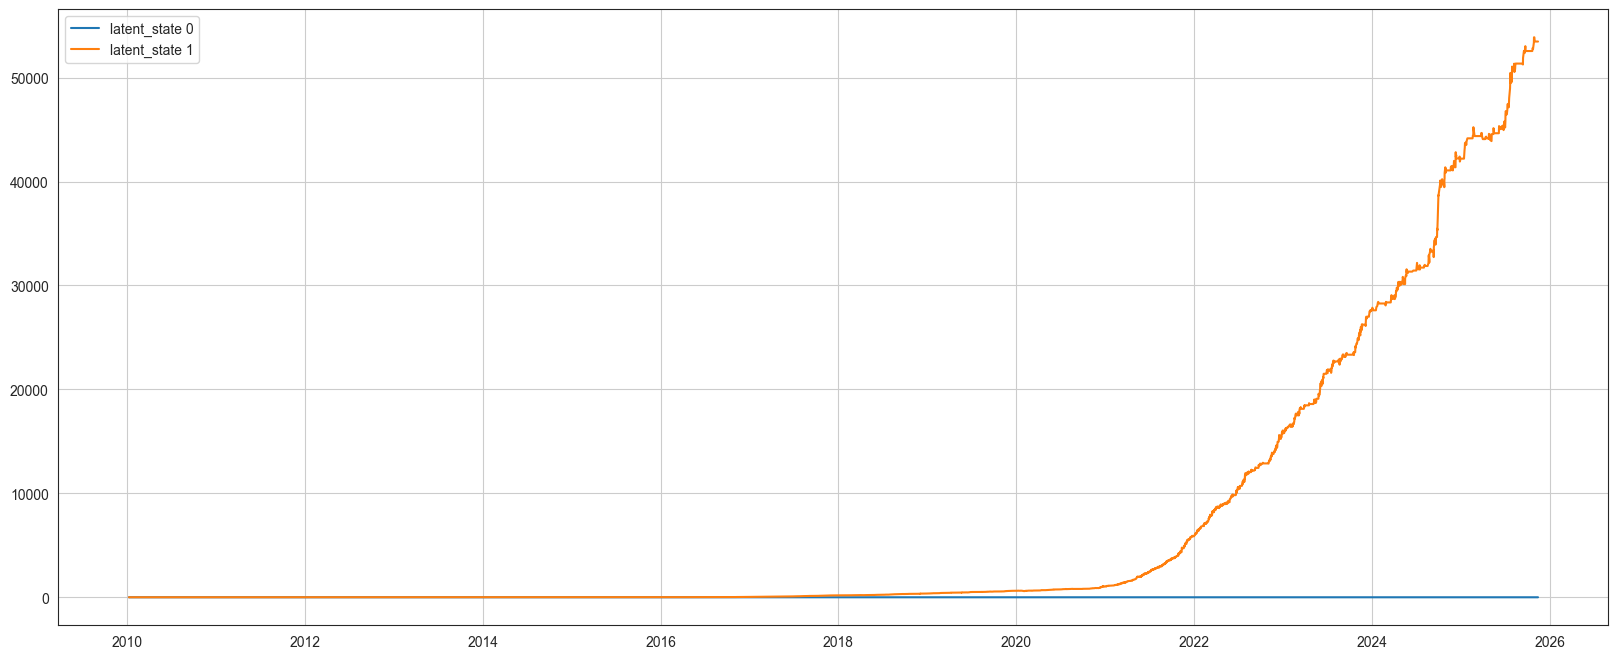

In [5]:
# 1. 构造包含日期、对数收益和隐状态的DataFrame，并以日期为索引
data = pd.DataFrame({'datelist':datelist,
                     'logreturn': logreturn,
                     'state': latent_states_sequence}).set_index('datelist')

plt.figure(figsize=(20, 8))

# 2. 对每个隐状态i，提取属于该状态的收益序列，其余置0
for i in range(gmm.n_components):
    # 生成布尔掩码：True表示当前时刻属于状态i
    state_mask = (latent_states_sequence == i)
    # 把第一行强制设为False，避免首行错位
    # idx：去掉首行标记的布尔掩码，首行置False，其余保持state_mask原值，用于避免首行错位
    idx = np.append(False, state_mask[1:])
    
    # 仅保留状态i的对数收益，其余为0
    data[f'state{i}_return'] = data.logreturn.multiply(idx, axis=0)
 
    # 3. 计算该状态累积收益并绘制净值曲线
    plt.plot(np.exp(data[f'state{i}_return'].cumsum()),
             label=f'latent_state {i}')
print(data.head(25))

plt.legend(loc='upper left')
plt.grid(True)

# 4. 保存图片
plt.savefig("Label_a.jpg")


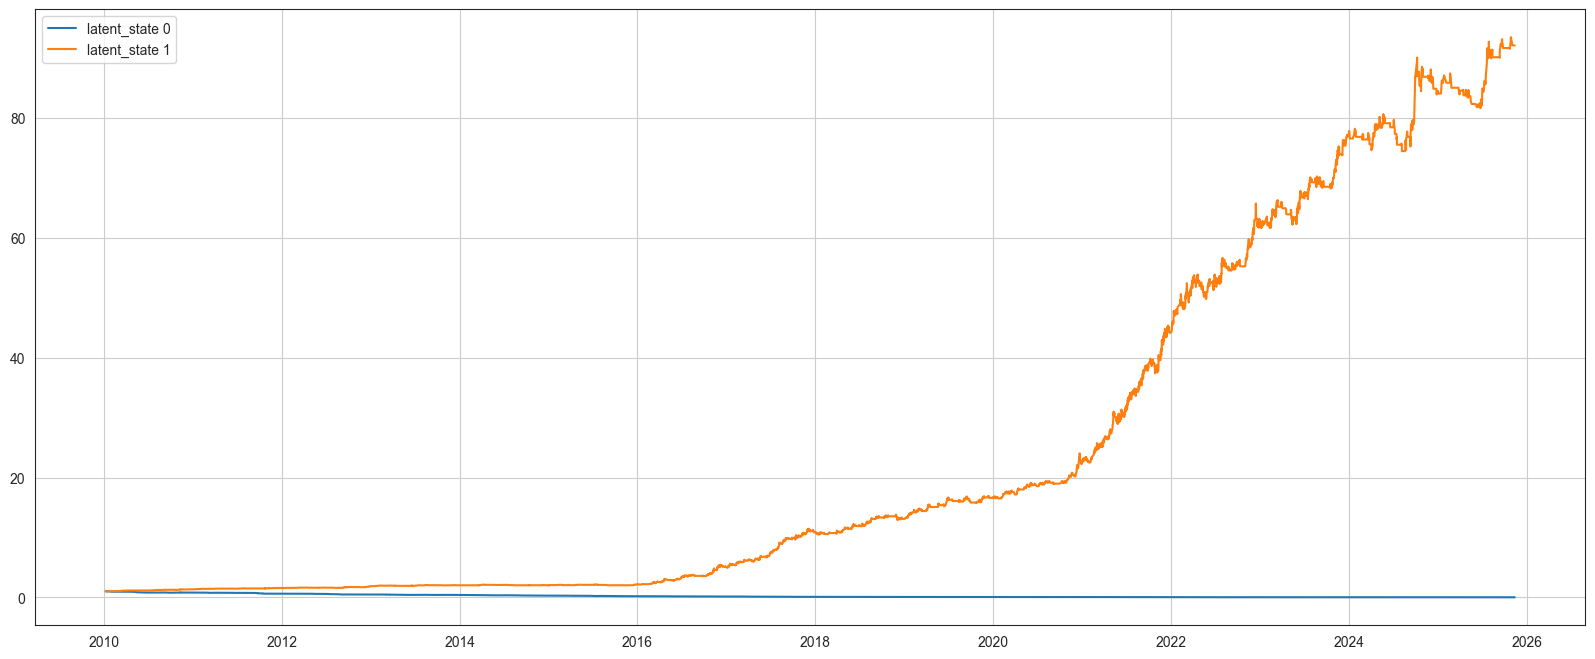

In [6]:
# 构建包含日期、对数收益和隐状态的DataFrame，并以日期为索引
data = pd.DataFrame({'datelist': datelist,
                     'logreturn': logreturn,
                     'state': latent_states_sequence}).set_index('datelist')

# 初始化画布
plt.figure(figsize=(20, 8))

# 遍历每个隐状态，提取对应的对数收益并累乘，绘制累积收益曲线
for i in range(gmm.n_components):
    # 生成布尔序列，标记当前状态
    state = (latent_states_sequence == i)
    # 构造索引：首项补0，其余取state[:-1]，确保收益从次日开始累乘
    idx = np.append(0, state[:-1])
    # 仅保留当前状态的对数收益，其余置0
    data['state %d_return' % i] = data.logreturn.multiply(idx, axis=0)
    # 计算并绘制该状态的累积收益（指数化后）
    plt.plot(np.exp(data['state %d_return' % i].cumsum()),
             label='latent_state %d' % i)
    plt.legend(loc='upper left')
    plt.grid(True)

# 保存结果图
plt.savefig("Label_b.jpg")  ##############  保存图片    #####################


In [7]:
# 自动判断，将标签的 1与0，变为buy为1，sell为0

if sum(data['state 0_return']) > sum(data['state 1_return']):
    data['state'] = abs(data['state'] - 1)
    
    
    
# 标签数据导出

data.to_csv(file + "_Label_" + str(L) + str(diff) + str(mix) + ".csv")   